<a href="https://colab.research.google.com/github/giovannaloro/AN2DL_PROJECT_2024_M2G/blob/main/EfficientnetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/MyDrive/[2024-2025] AN2DL HOMEWORK 1/Definitive_work

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/.shortcut-targets-by-id/117Cy5jmRvw7kUjsl1Y2WzOeI_SAmudjh/[2024-2025] AN2DL HOMEWORK 1/Definitive_work


In [53]:
# Fix randomness and hide warnings
SEED = 42  # Random seed for reproducibility

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers as tfkl
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adadelta
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

# Importing specific TensorFlow Keras layers
from tensorflow.keras.layers import (
    Input, Concatenate, Dense, GlobalAveragePooling2D, Dropout,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomBrightness
)

# Set seed for TensorFlow
tf.random.set_seed(SEED)
tf.compat.v1.set_random_seed(SEED)

# Reduce TensorFlow verbosity
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Print TensorFlow version
print(tf.__version__)

# Import other libraries
# Import other libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from PIL import Image
import matplotlib.gridspec as gridspec
from datetime import datetime

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

2.17.1


In [54]:
# Load already preprocessed dataset
data = np.load('preprocessed_dataset.npz')
X_train = data['X_train']
X_test = data['X_test']
X_val = data['X_val']
y_train = data['y_train']
y_test = data['y_test']
y_val = data['y_val']

In [55]:
# Convert one-hot encoded labels to integer labels
if y_train.ndim > 1:
    y_int_train = np.argmax(y_train, axis=1)  # Flatten the one-hot labels to class indices
else:
    y_int_train = y_train  # Already in integer format

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_int_train), y=y_int_train)
class_weights = dict(enumerate(class_weights))

In [56]:
# Define data augmentation
data_augmentation = tf.keras.Sequential([
   RandomFlip('horizontal'),  # Flip images horizontally
   RandomRotation(0.3),  # Rotate images
   RandomContrast(0.3),  # Random contrast
   RandomBrightness(0.1),  # Random brightness
   RandomZoom(0.2),  # Random zoom
])


In [57]:
import tensorflow as tf
tfk = tf.keras

# Parameters
INPUT_SHAPE = X_train.shape[1:]
OUTPUT_SHAPE = y_train.shape[1]
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-4
EPOCHS = 35
FINE_TUNE_EPOCHS = 15

# Create an EarlyStopping callback
early_stopping = tfk.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

callbacks = [early_stopping]


In [69]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers as tfkl, models


# Clear previous models/sessions
tf.keras.backend.clear_session()

# Create input layer
inputs = tfkl.Input(shape=INPUT_SHAPE)

# Define the base model with EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze the base model initially
base_model.trainable = False

# Apply data augmentation to inputs
x = data_augmentation(inputs)

# Apply EfficientNetB0 specific preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Pass augmented inputs through the base model
x = base_model(x)

# Apply Global Average Pooling (GAP) to reduce the tensor dimensions
x = tfkl.GlobalAveragePooling2D()(x)

# Add dense and dropout layers
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)

# Define the output layer
outputs = tfkl.Dense(OUTPUT_SHAPE, activation='softmax')(x)

# Create the model
model = models.Model(inputs=inputs, outputs=outputs)


In [59]:
# First phase: Train only the top layers
model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=[tfk.metrics.F1Score(average='macro')]
)

# Print the model summary
model.summary(expand_nested=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ random_flip (RandomFlip)        │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ random_rotation                 │ (None, 96, 96, 3)           │               0 │
│ (RandomRotation)                     │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ random_contrast                 │ (None, 96, 96, 3)           │               0 │
│ (RandomContrast)                     │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ random_brightness               │ (None, 96, 96, 3)           │               0 │
│ (RandomBrightness)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ random_zoom (RandomZoom)        │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 3, 3, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ rescaling (Rescaling)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ normalization (Normalization)   │ (None, 96, 96, 3)           │               7 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ stem_conv_pad (ZeroPadding2D)   │ (None, 97, 97, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ stem_conv (Conv2D)              │ (None, 48, 48, 32)          │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ stem_bn (BatchNormalization)    │ (None, 48, 48, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ stem_activation (Activation)    │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block1a_dwconv                  │ (None, 48, 48, 32)          │             288 │
│ (DepthwiseConv2D)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block1a_bn (BatchNormalization) │ (None, 48, 48, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block1a_activation (Activation) │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,132,075 (15.76 MB)

 Trainable params: 82,504 (322.28 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [60]:
# Transfer learning
history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights
).history

# Print score
final_val_F1Score2 = round(max(history['val_f1_score'])* 100, 2)
print(f'Transfer learning validation F1Score: {final_val_F1Score2}%')

Epoch 1/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - f1_score: 0.4436 - loss: 2.4080 - val_f1_score: 0.7333 - val_loss: 1.2052
Epoch 2/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - f1_score: 0.7164 - loss: 1.1665 - val_f1_score: 0.8133 - val_loss: 0.8273
Epoch 3/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - f1_score: 0.7608 - loss: 0.8950 - val_f1_score: 0.8005 - val_loss: 0.7827
Epoch 4/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - f1_score: 0.7774 - loss: 0.8231 - val_f1_score: 0.8254 - val_loss: 0.6911
Epoch 5/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - f1_score: 0.7923 - loss: 0.7525 - val_f1_score: 0.8226 - val_loss: 0.6720
Epoch 6/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - f1_score: 0.7951 - loss: 0.7310 - val_f1_score: 0.8392 - val_loss: 0.6452
Epoch 7/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - f1_score: 0.7932 - loss: 0.7194 - val_f1_score: 0.8267 - val_loss: 0.6452
Epoch 8/35
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - f1_score: 0.7990 - loss: 0.6942 - val_f1_score: 0.8449

In [61]:

# UNFREEZE RELATIVE TO MODEL
def unfreeze_model(model, num_layers_to_unfreeze=100):
    # Get the base model (EfficientNetB0)
    base_model = model.layers[2]  # Assuming the base model is the third layer in your model

    # Unfreeze the base model
    base_model.trainable = True

    # Calculate the number of layers to keep frozen
    num_layers = len(base_model.layers)
    freeze_until = num_layers - num_layers_to_unfreeze

    # Freeze layers until the specified point
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False

    # Unfreeze layers after the specified point, but keep BatchNormalization layers frozen
    for layer in base_model.layers[freeze_until:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False

    # Print summary of trainable layers
    trainable_count = sum(layer.trainable for layer in base_model.layers)
    total_count = len(base_model.layers)
    print(f"Trainable layers: {trainable_count}/{total_count}")

    # Ensure top layers are trainable
    for layer in model.layers[2:]:  # Assuming base_model is followed by your custom layers
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro')]
    )

    return model

model = unfreeze_model(model)


Trainable layers: 80/238


In [62]:
# Fine-tuning
history_fine = model.fit(
    x=X_train,
    y=y_train,
    batch_size=BATCH_SIZE,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights
).history


Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - f1_score: 0.8355 - loss: 0.5684 - val_f1_score: 0.9177 - val_loss: 0.3726
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - f1_score: 0.8907 - loss: 0.4231 - val_f1_score: 0.9128 - val_loss: 0.3952
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - f1_score: 0.9115 - loss: 0.3700 - val_f1_score: 0.9263 - val_loss: 0.3426
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - f1_score: 0.9166 - loss: 0.3414 - val_f1_score: 0.9443 - val_loss: 0.2950
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - f1_score: 0.9276 - loss: 0.3042 - val_f1_score: 0.9447 - val_loss: 0.2874
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - f1_score: 0.9348 - loss: 0.2852 - val_f1_score: 0.9549 - val_loss: 0.2493
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - f1_score: 0.9331 - loss: 0.2721 - val_f1_score: 0.9443 - val_loss: 0.2648
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - f1_score: 0.9362 - loss: 0.2583 - val_f1_score: 0.942

In [63]:

# Print score
final_val_F1Score1 = round(max(history['val_f1_score'])* 100, 2)
print(f'Fine-tuning validation F1Score: {final_val_F1Score2}%')


Fine-tuning validation F1Score: 86.25%


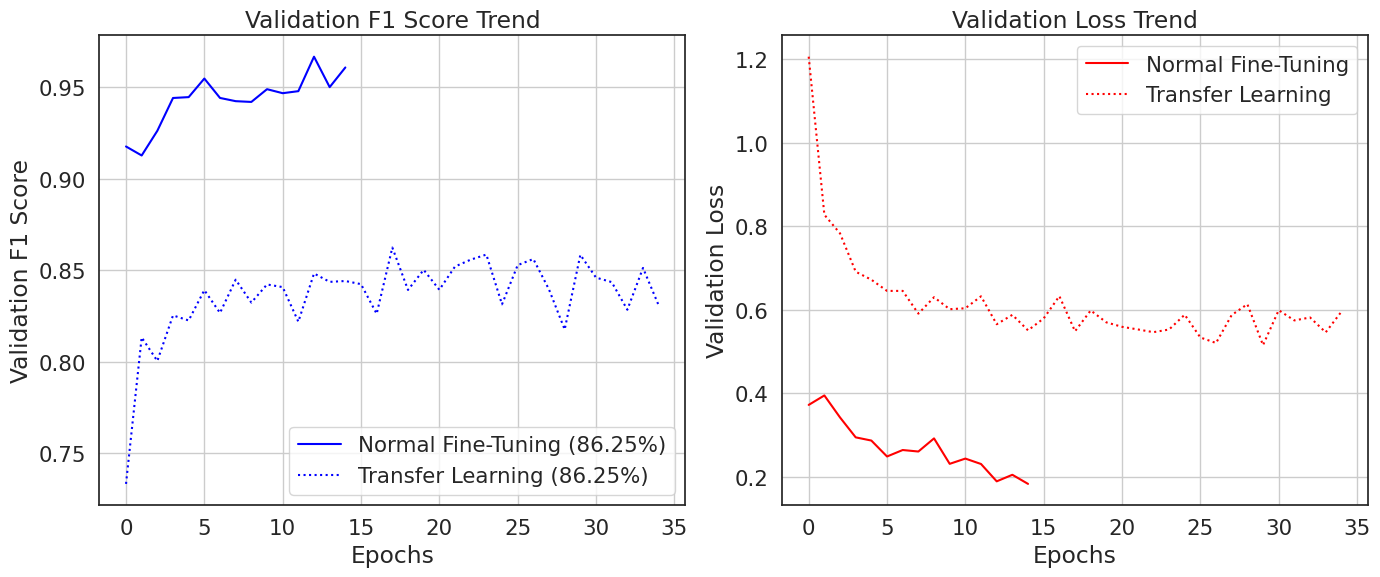

In [64]:
plt.figure(figsize=(14, 6))

# Plot 1: Validation F1 Score trend
plt.subplot(1, 2, 1)
plt.plot(history_fine['val_f1_score'], label=f'Normal Fine-Tuning ({final_val_F1Score1}%)', color='blue', linestyle='-')
plt.plot(history['val_f1_score'], label=f'Transfer Learning ({final_val_F1Score2}%)', color='blue', linestyle=':')
plt.title('Validation F1 Score Trend')
plt.xlabel('Epochs')
plt.ylabel('Validation F1 Score')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Validation Loss trend
plt.subplot(1, 2, 2)
plt.plot(history_fine['val_loss'], label='Normal Fine-Tuning', color='red', linestyle='-')
plt.plot(history['val_loss'], label='Transfer Learning', color='red', linestyle=':')
plt.title('Validation Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step
Accuracy score over the test set: 0.1446
Precision score over the test set: 0.2118
Recall score over the test set: 0.1446
F1 score over the test set: 0.1027


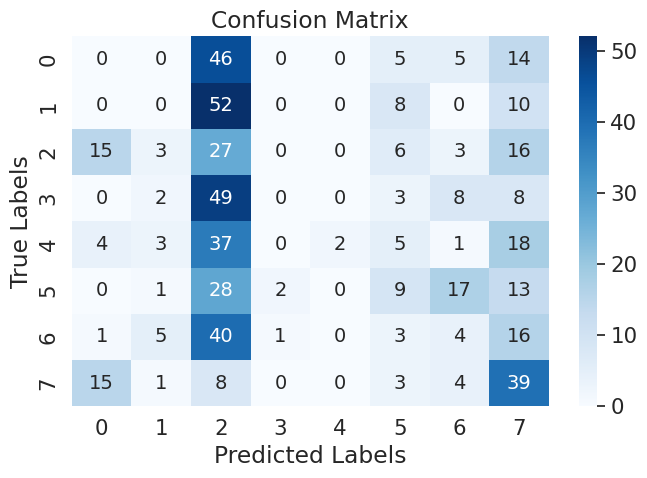

In [70]:
# Load model1 and model2 if necessary (if models were deleted after training)
#model = tf.keras.models.load_model(model_filename)

# Make predictions for model1 on the test set
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Calculate and display test set accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy score over the test set: {round(test_accuracy, 4)}')
test_precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision score over the test set: {round(test_precision, 4)}')
test_recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall score over the test set: {round(test_recall, 4)}')
test_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 score over the test set: {round(test_f1, 4)}')

# Compute confusion matrices for both models
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.show()


In [65]:

# Save the trained model to a file
model_filename = 'EfficientnetB0.keras' # CHANGE TO SPECIFIC MODEL
model.save(model_filename)

# Delete the model to free up resources
#del model